# Purpose

Design NPS resin for new [Elegoo Mars 4 Ultra](https://us.elegoo.com/products/elegoo-mars-4-ultra-msla-resin-3d-printer-with-9k-mono-lcd#specification) LCD 3D printer, which has 18 &mu;m pixel size and 405 nm LED source. Use measured LED spectrum, `Elegoo_405nm_Mars4_Ultra_2024-05-16`. Want to use 20 &mu;m layers so need optical penetration depth of resin to be about 25 &mu;m for a normalized layer thickness ($l/h_a$) of 0.8. (A value of 0.75 leads to an h_a of 26.67 &mu;m.)

# Imports

In [1]:
from pathlib import Path
import typing

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import matplotlib
#%matplotlib widget
%matplotlib inline

from scipy.optimize import curve_fit
import scipy.integrate as integrate

import spectra.data as data
from spectra.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from spectra.sourcespectrum import SourceSpectrum
from spectra.utilities import ArrayParams
from spectra.irradiance import Irradiance
from spectra.normalizeddose import NormalizedDose

In [2]:
import sys
!{sys.executable} --version

Python 3.12.2


# Available spectrum data

In [3]:
data.sources

{'365nm_visitech_with_50mm_asahi_filter_2018-11-22': <spectra.sourcespectrum.SourceSpectrum at 0x12e77a1e0>,
 'Asiga_405nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x12e77a2a0>,
 'Elegoo_405nm_Mars4_Ultra_2024-05-16': <spectra.sourcespectrum.SourceSpectrum at 0x12e77a330>,
 'HR1_385nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x12e77a390>,
 'HR2_385nm_2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x12e77a3f0>,
 'HR3.2_365nm_370nm_short_pass_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x12e77a450>,
 'HR3.2_365nm_no_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x12e77a480>,
 'HR3.3_365nm_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x12e77a4e0>,
 'HR3.3_365nm_no_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x12e77a540>,
 'HR3.3_365nm_through_tray_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x12e77a270>,
 'HR3.

In [4]:
data.absorbers

{'avobenzone_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12e778ce0>,
 'avobenzone_in_PEGDA_2020-01-20': <spectra.absorberspectrum.AbsorberSpectrum at 0x11fcea180>,
 'benetex_obplus_in PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x11fbd0bc0>,
 'bls99-2_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12e778e00>,
 'ideal_uniform_absorber': <spectra.absorberspectrum.AbsorberSpectrum at 0x12e480b00>,
 'martius_yellow_in PEGDA_2020-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12e779010>,
 'nps_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12e779070>,
 'octocrylene_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12e779220>,
 'phenazine_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12e779340>,
 'salicylaldehyde_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12e779430>,
 'sudanI_in_PEGDA_2017-04-13': <spectra.absorberspectru

In [5]:
data.monomers

{'HDDA': Monomer(/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/monomers/hdda.json),
 'Ideal': Monomer(/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/monomers/ideal.json),
 'PEGDA': Monomer(/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/monomers/pegda.json),
 'TET': Monomer(/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/monomers/tet.json)}

# Elegoo 405 nm LED spectrum

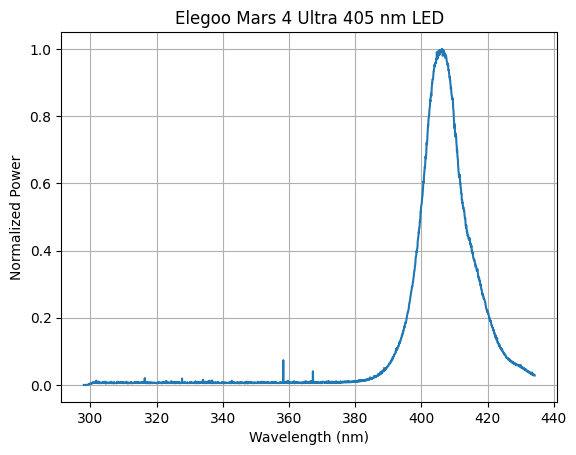

In [6]:
source = data.sources['Elegoo_405nm_Mars4_Ultra_2024-05-16']

fig, ax = plt.subplots()
ax.plot(source.wavelength, source.power)
ax.set_ylabel("Normalized Power")
ax.set_xlabel("Wavelength (nm)")
ax.set_title("Elegoo Mars 4 Ultra 405 nm LED")
ax.grid()

## Compare to other 405 nm LED spectra

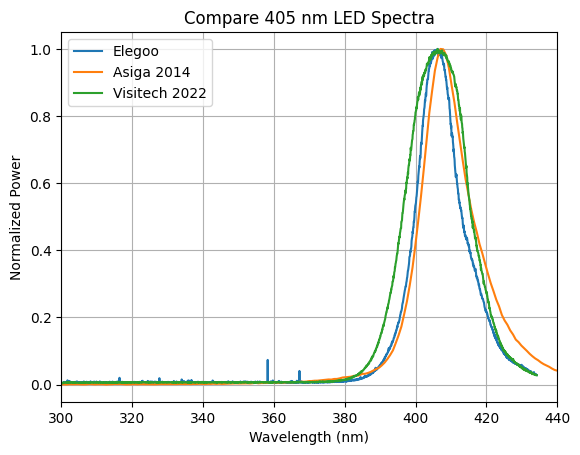

In [7]:
source_asiga = data.sources['Asiga_405nm_100um_fiber-2016-12-14']
source_visitech = data.sources['MR1_405nm_Visitech_unfiltered_2022-08-12']

fig, ax = plt.subplots()
ax.plot(source.wavelength, source.power, label="Elegoo")
ax.plot(source_asiga.wavelength, source_asiga.power, label="Asiga 2014")
ax.plot(source_visitech.wavelength, source_visitech.power, label="Visitech 2022")
ax.set_xlim(300, 440)
ax.set_ylabel("Normalized Power")
ax.set_xlabel("Wavelength (nm)")
ax.set_title("Compare 405 nm LED Spectra")
ax.legend()
ax.grid()

# Initialize parameters

## Resins

In [8]:
# Create resin
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
nps_3p0 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    3.0
)
nps_2p7 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    2.7
)
nps_2p0 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    2.0
)
nps_1p0 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    1.0
)
nps_0p5 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    0.5
)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)
resin_nps3p0 = Resin(monomers=pegda, absorbers=nps_3p0, photoinitiators=irgacure819)
resin_nps2p7 = Resin(monomers=pegda, absorbers=nps_2p7, photoinitiators=irgacure819)
resin_nps2p0 = Resin(monomers=pegda, absorbers=nps_2p0, photoinitiators=irgacure819)
resin_nps1p0 = Resin(monomers=pegda, absorbers=nps_1p0, photoinitiators=irgacure819)
resin_nps0p5 = Resin(monomers=pegda, absorbers=nps_0p5, photoinitiators=irgacure819)
print(f"{resin_nps3p0.name=}")
print(f"{resin_nps2p7.name=}")
print(f"{resin_nps2p0.name=}")
print(f"{resin_nps1p0.name=}")
print(f"{resin_nps0p5.name=}")

resin_nps3p0.name='PEG-100__NPS-3__Irg-1'
resin_nps2p7.name='PEG-100__NPS-2.7__Irg-1'
resin_nps2p0.name='PEG-100__NPS-2__Irg-1'
resin_nps1p0.name='PEG-100__NPS-1__Irg-1'
resin_nps0p5.name='PEG-100__NPS-0.5__Irg-1'


## Wavelength sampling array parameters

In [9]:
wavelength_array_parameters = ArrayParams(300, 440, 401)

# Calculations

In [10]:
irradiance_nps3p0 = Irradiance(source=source, resin=resin_nps3p0, wavelength_array_params=wavelength_array_parameters)
irradiance_nps2p7 = Irradiance(source=source, resin=resin_nps2p7, wavelength_array_params=wavelength_array_parameters)
irradiance_nps2p0 = Irradiance(source=source, resin=resin_nps2p0, wavelength_array_params=wavelength_array_parameters)
irradiance_nps1p0 = Irradiance(source=source, resin=resin_nps1p0, wavelength_array_params=wavelength_array_parameters)
irradiance_nps0p5 = Irradiance(source=source, resin=resin_nps0p5, wavelength_array_params=wavelength_array_parameters)

In [11]:
z_array_params = ArrayParams(0, 100, 201)

PEG-100__NPS-3__Irg-1


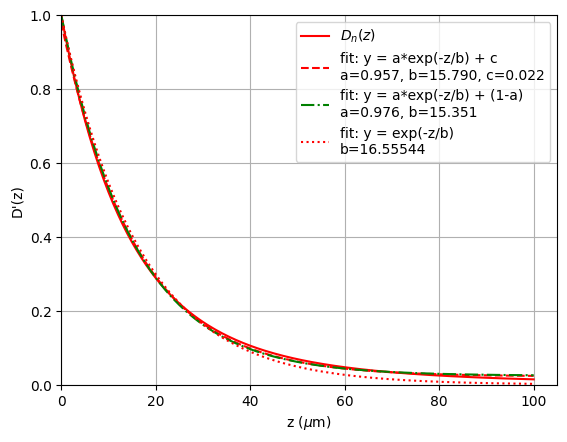

In [12]:
# Normalized dose
norm_dose_nps3p0 = NormalizedDose(irradiance=irradiance_nps3p0, z_array_params=z_array_params)
print(norm_dose_nps3p0.irradiance.resin.name)
norm_dose_nps3p0.plot();

PEG-100__NPS-2.7__Irg-1


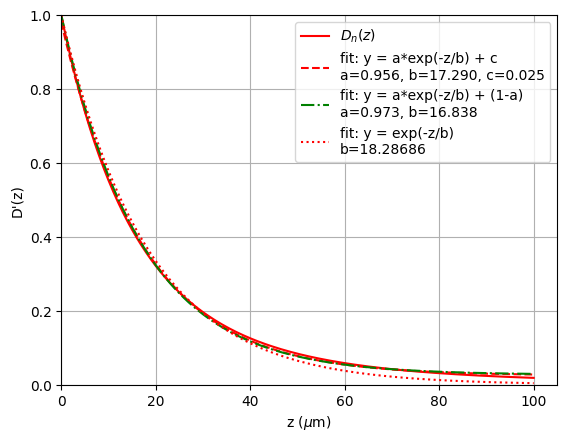

In [13]:
# Normalized dose
norm_dose_nps2p7 = NormalizedDose(irradiance=irradiance_nps2p7, z_array_params=z_array_params)
print(norm_dose_nps2p7.irradiance.resin.name)
norm_dose_nps2p7.plot();

In [14]:
for i in range(45):
    print(f" {i:2d} {norm_dose_nps2p7.z_um[i]:4.1f} {norm_dose_nps2p7.normalized_dose[i]:.3f}")

  0  0.0 1.000
  1  0.5 0.970
  2  1.0 0.940
  3  1.5 0.912
  4  2.0 0.885
  5  2.5 0.858
  6  3.0 0.833
  7  3.5 0.808
  8  4.0 0.784
  9  4.5 0.761
 10  5.0 0.739
 11  5.5 0.717
 12  6.0 0.696
 13  6.5 0.676
 14  7.0 0.657
 15  7.5 0.638
 16  8.0 0.620
 17  8.5 0.602
 18  9.0 0.585
 19  9.5 0.569
 20 10.0 0.553
 21 10.5 0.537
 22 11.0 0.523
 23 11.5 0.508
 24 12.0 0.494
 25 12.5 0.481
 26 13.0 0.467
 27 13.5 0.455
 28 14.0 0.442
 29 14.5 0.431
 30 15.0 0.419
 31 15.5 0.408
 32 16.0 0.397
 33 16.5 0.387
 34 17.0 0.376
 35 17.5 0.366
 36 18.0 0.357
 37 18.5 0.348
 38 19.0 0.339
 39 19.5 0.330
 40 20.0 0.322
 41 20.5 0.313
 42 21.0 0.305
 43 21.5 0.298
 44 22.0 0.290


PEG-100__NPS-2__Irg-1


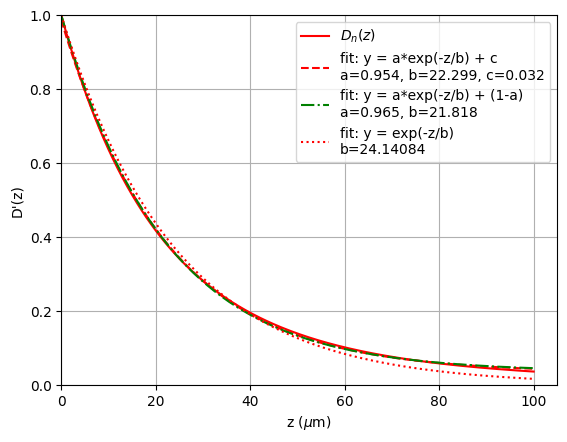

In [15]:
# Normalized dose
norm_dose_nps2p0 = NormalizedDose(irradiance=irradiance_nps2p0, z_array_params=z_array_params)
print(norm_dose_nps2p0.irradiance.resin.name)
norm_dose_nps2p0.plot();

PEG-100__NPS-1__Irg-1


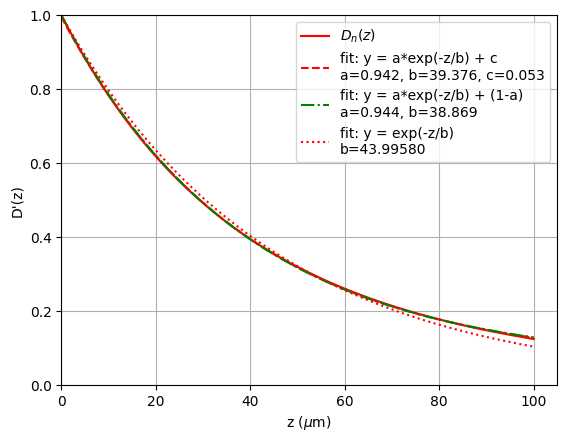

In [16]:
# Normalized dose
norm_dose_nps1p0 = NormalizedDose(irradiance=irradiance_nps1p0, z_array_params=z_array_params)
print(norm_dose_nps1p0.irradiance.resin.name)
norm_dose_nps1p0.plot();

PEG-100__NPS-0.5__Irg-1


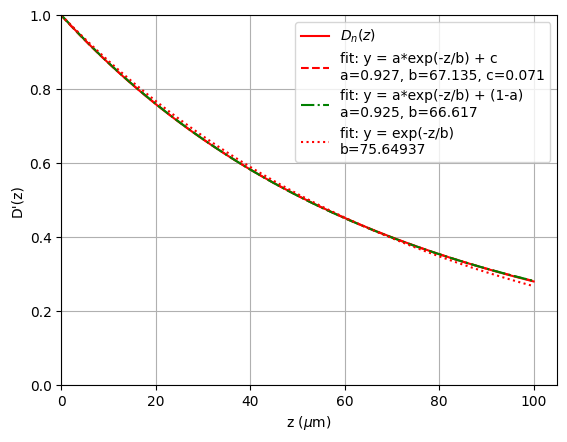

In [17]:
# Normalized dose
norm_dose_nps0p5 = NormalizedDose(irradiance=irradiance_nps0p5, z_array_params=z_array_params)
print(norm_dose_nps0p5.irradiance.resin.name)
norm_dose_nps0p5.plot();

# Optical penetration depth, b, vs NPS concentration

In [18]:
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)

nps_conc_values = np.linspace(0.5, 2.0, num=16)
optical_penetration_depth = []

for nps_conc in nps_conc_values:
    absorber = ResinConstituentAbsorber(
        data.absorbers['nps_in_PEGDA_2017-04-13'],
        nps_conc
    )
    resin = Resin(monomers=pegda, absorbers=absorber, photoinitiators=irgacure819)
    irradiance = Irradiance(source=source, resin=resin, wavelength_array_params=wavelength_array_parameters)
    norm_dose = NormalizedDose(irradiance=irradiance, z_array_params=z_array_params)
    optical_penetration_depth.append(norm_dose.a_b_model_params['b'])
    

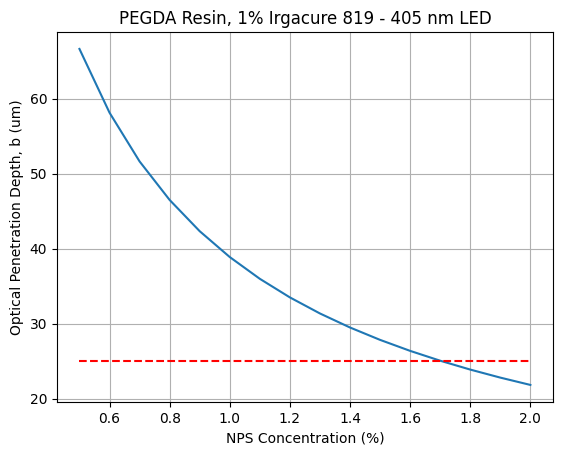

In [19]:
fig, ax = plt.subplots()
ax.plot(nps_conc_values, optical_penetration_depth)
ax.set_xlabel("NPS Concentration (%)")
ax.set_ylabel("Optical Penetration Depth, b (um)")
ax.set_title("PEGDA Resin, 1% Irgacure 819 - 405 nm LED")
ax.hlines(25, 0.5, 2.0, color="r", ls="--")
ax.grid()
plt.savefig("h_a_vs_NPS_concentration.png")

In [20]:
print("NPS conc. (%) | Optical penetration depth (um)")
print("----------------------------------------------")
for conc, h_a in zip(nps_conc_values, optical_penetration_depth):
    print(f"      {conc:0.2f}    |      {h_a:.2f}")

NPS conc. (%) | Optical penetration depth (um)
----------------------------------------------
      0.50    |      66.62
      0.60    |      58.12
      0.70    |      51.62
      0.80    |      46.48
      0.90    |      42.32
      1.00    |      38.87
      1.10    |      35.97
      1.20    |      33.49
      1.30    |      31.35
      1.40    |      29.48
      1.50    |      27.83
      1.60    |      26.36
      1.70    |      25.05
      1.80    |      23.86
      1.90    |      22.79
      2.00    |      21.82


# NPS 1.7%

PEG-100__NPS-1.7__Irg-1


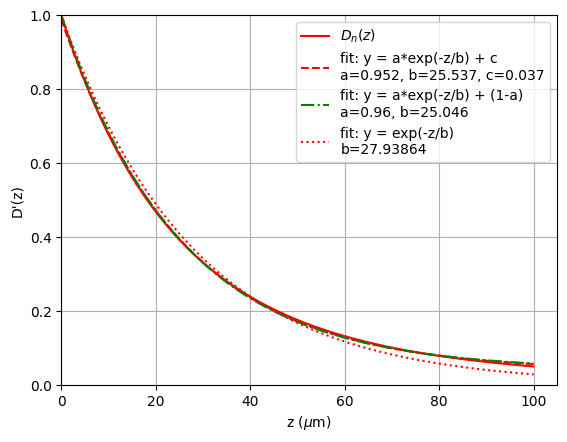

In [21]:
nps_1p7 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    1.7
)
resin_nps1p7 = Resin(monomers=pegda, absorbers=nps_1p7, photoinitiators=irgacure819)
# print(f"{resin_nps1p7.name=}")

irradiance_nps1p7 = Irradiance(source=source, resin=resin_nps1p7, wavelength_array_params=wavelength_array_parameters)

# Normalized dose
norm_dose_nps1p7 = NormalizedDose(irradiance=irradiance_nps1p7, z_array_params=z_array_params)
print(norm_dose_nps1p7.irradiance.resin.name)
norm_dose_nps1p7.plot();

In [22]:
for i in range(40,55):
    print(f" {i:2d} {norm_dose_nps1p7.z_um[i]:4.1f} {norm_dose_nps1p7.normalized_dose[i]:.3f}")

 40 20.0 0.468
 41 20.5 0.460
 42 21.0 0.452
 43 21.5 0.444
 44 22.0 0.436
 45 22.5 0.428
 46 23.0 0.421
 47 23.5 0.413
 48 24.0 0.406
 49 24.5 0.399
 50 25.0 0.392
 51 25.5 0.386
 52 26.0 0.379
 53 26.5 0.372
 54 27.0 0.366


In [23]:
np.exp(-1)

0.36787944117144233

# Normalized dose at z=25 &mu;m vs NPS concentration

Instead of choosing the NPS concentration on the basis of the fitted `b` parameter being 25 &mu;m, let's set the concentration so that the normalized dose is 1/e at z=25 &mu;m, which mimics the situation when we have full coverage of the source spectrum by the absorber spectrum. The index of 25 &mu;m in the z array is 50.

In [24]:
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)

nps_conc_values = np.linspace(0.5, 3.0, num=26)
normalized_dose_at_25um = []
index_for_z_equal_25um = 50

for nps_conc in nps_conc_values:
    absorber = ResinConstituentAbsorber(
        data.absorbers['nps_in_PEGDA_2017-04-13'],
        nps_conc
    )
    resin = Resin(monomers=pegda, absorbers=absorber, photoinitiators=irgacure819)
    irradiance = Irradiance(source=source, resin=resin, wavelength_array_params=wavelength_array_parameters)
    norm_dose = NormalizedDose(irradiance=irradiance, z_array_params=z_array_params)
    normalized_dose_at_25um.append(norm_dose.normalized_dose[index_for_z_equal_25um])


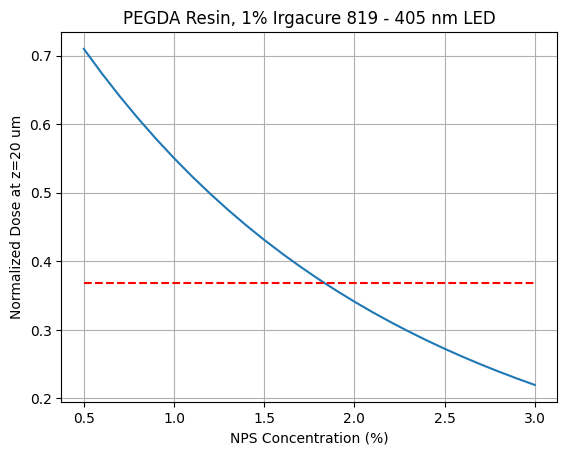

In [25]:
fig, ax = plt.subplots()
ax.plot(nps_conc_values, normalized_dose_at_25um)
ax.set_xlabel("NPS Concentration (%)")
ax.set_ylabel("Normalized Dose at z=20 um")
ax.set_title("PEGDA Resin, 1% Irgacure 819 - 405 nm LED")
ax.hlines(np.exp(-1), 0.5, 3.0, color="r", ls="--")
ax.grid()
# plt.savefig("h_a_vs_NPS_concentration.png")

In [26]:
print("NPS conc. (%) | Normalized Dose at z=20 um")
print("------------------------------------------")
for conc, h_a in zip(nps_conc_values, normalized_dose_at_25um):
    print(f"      {conc:0.2f}    |      {h_a:.4f}")

NPS conc. (%) | Normalized Dose at z=20 um
------------------------------------------
      0.50    |      0.7098
      0.60    |      0.6740
      0.70    |      0.6404
      0.80    |      0.6087
      0.90    |      0.5788
      1.00    |      0.5505
      1.10    |      0.5239
      1.20    |      0.4987
      1.30    |      0.4750
      1.40    |      0.4525
      1.50    |      0.4313
      1.60    |      0.4112
      1.70    |      0.3923
      1.80    |      0.3743
      1.90    |      0.3573
      2.00    |      0.3412
      2.10    |      0.3260
      2.20    |      0.3115
      2.30    |      0.2978
      2.40    |      0.2849
      2.50    |      0.2726
      2.60    |      0.2609
      2.70    |      0.2498
      2.80    |      0.2393
      2.90    |      0.2293
      3.00    |      0.2198


## Linearly interpolate concentration

In [27]:
np.exp(-1)

0.36787944117144233

In [28]:
x1,y1 = 1.80, 0.3743
x2,y2 = 1.90, 0.3573
a = (y2 - y1) / (x2 - x1)
desired_concentration = (np.exp(-1) - y1) / a + x1
desired_concentration

1.8377679931091628

# NPS 1.84%

PEG-100__NPS-1.84__Irg-1


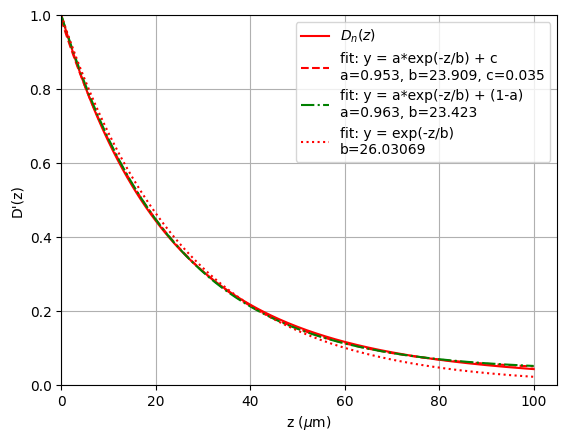

In [29]:
nps_1p84 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    1.84
)
resin_nps1p84 = Resin(monomers=pegda, absorbers=nps_1p84, photoinitiators=irgacure819)
# print(f"{resin_nps1p7.name=}")

irradiance_nps1p84 = Irradiance(source=source, resin=resin_nps1p84, wavelength_array_params=wavelength_array_parameters)

# Normalized dose
norm_dose_nps1p84 = NormalizedDose(irradiance=irradiance_nps1p84, z_array_params=z_array_params)
print(norm_dose_nps1p84.irradiance.resin.name)
norm_dose_nps1p84.plot();

In [30]:
z_layer_um = 20.0
z_positions_um = z_layer_um * np.array([i for i in range(0, 11)])
z_positions_um

array([  0.,  20.,  40.,  60.,  80., 100., 120., 140., 160., 180., 200.])

In [31]:
for i in range(40,55):
    print(f" {i:2d} {norm_dose_nps1p84.z_um[i]:4.1f} {norm_dose_nps1p84.normalized_dose[i]:.3f}")

 40 20.0 0.443
 41 20.5 0.435
 42 21.0 0.427
 43 21.5 0.419
 44 22.0 0.411
 45 22.5 0.403
 46 23.0 0.396
 47 23.5 0.388
 48 24.0 0.381
 49 24.5 0.374
 50 25.0 0.367
 51 25.5 0.361
 52 26.0 0.354
 53 26.5 0.348
 54 27.0 0.341


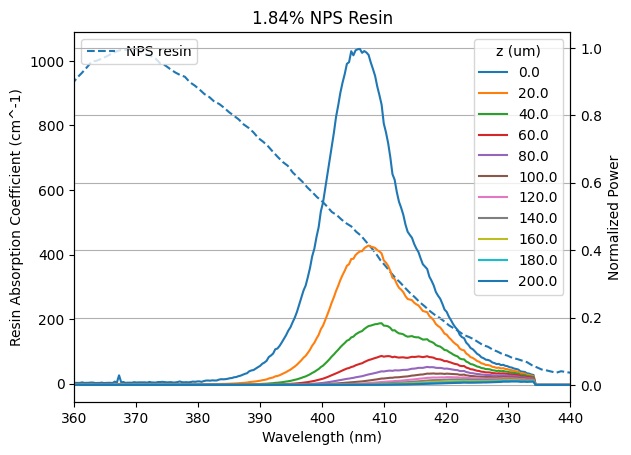

In [32]:
fig, ax = plt.subplots()
ax_right = ax.twinx()
for z in z_positions_um:
    ax_right.plot(irradiance_nps1p84.wavelengths, irradiance_nps1p84(z), label=z)
ax.set_xlim(360, 440)
ax.plot(resin_nps1p84.wavelength, resin_nps1p84.absorption_coeff_inv_cm, ls="--", label="NPS resin")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Resin Absorption Coefficient (cm^-1)")
ax_right.set_ylabel("Normalized Power")
ax_right.legend(title="z (um)")
ax.legend(loc="upper left")
ax.set_title("1.84% NPS Resin")
ax_right.grid()

# NPS 1.8%

PEG-100__NPS-1.8__Irg-1


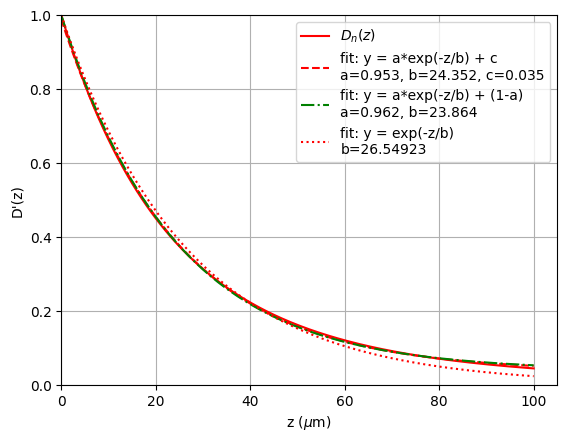

In [33]:
nps_1p8 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    1.8
)
resin_nps1p8 = Resin(monomers=pegda, absorbers=nps_1p8, photoinitiators=irgacure819)
# print(f"{resin_nps1p7.name=}")

irradiance_nps1p8 = Irradiance(source=source, resin=resin_nps1p8, wavelength_array_params=wavelength_array_parameters)

# Normalized dose
norm_dose_nps1p8 = NormalizedDose(irradiance=irradiance_nps1p8, z_array_params=z_array_params)
print(norm_dose_nps1p8.irradiance.resin.name)
norm_dose_nps1p8.plot();

In [34]:
for i in range(40,55):
    print(f" {i:2d} {norm_dose_nps1p8.z_um[i]:4.1f} {norm_dose_nps1p8.normalized_dose[i]:.3f}")

 40 20.0 0.450
 41 20.5 0.442
 42 21.0 0.434
 43 21.5 0.426
 44 22.0 0.418
 45 22.5 0.410
 46 23.0 0.403
 47 23.5 0.395
 48 24.0 0.388
 49 24.5 0.381
 50 25.0 0.374
 51 25.5 0.368
 52 26.0 0.361
 53 26.5 0.355
 54 27.0 0.348


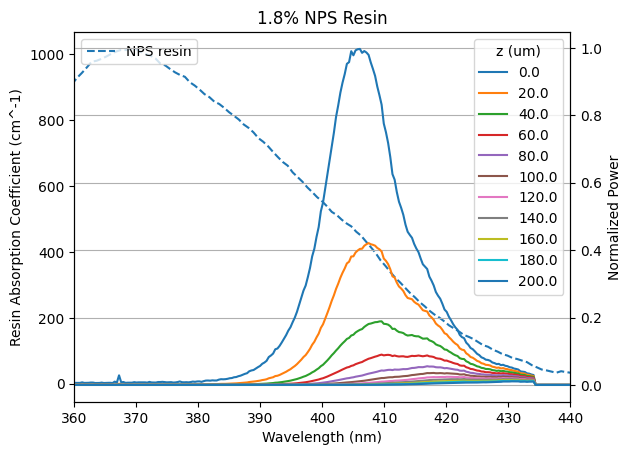

In [35]:
fig, ax = plt.subplots()
ax_right = ax.twinx()
for z in z_positions_um:
    ax_right.plot(irradiance_nps1p8.wavelengths, irradiance_nps1p8(z), label=z)
ax.set_xlim(360, 440)
ax.plot(resin_nps1p8.wavelength, resin_nps1p8.absorption_coeff_inv_cm, ls="--", label="NPS resin")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Resin Absorption Coefficient (cm^-1)")
ax_right.set_ylabel("Normalized Power")
ax_right.legend(title="z (um)")
ax.legend(loc="upper left")
ax.set_title("1.8% NPS Resin")
ax_right.grid()

# OLD

# NPS 2.3%

PEG-100__NPS-2.3__Irg-1


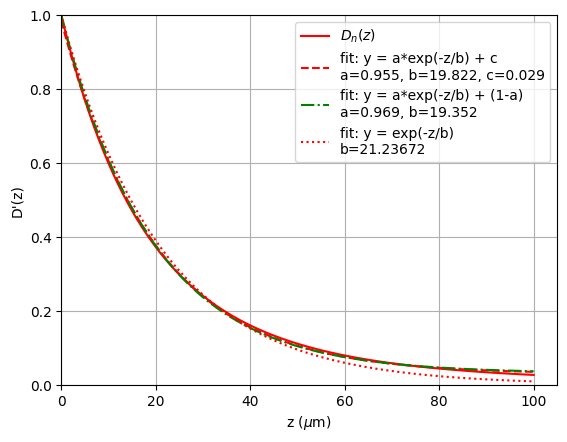

In [36]:
nps_2p3 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    2.3
)
resin_nps2p3 = Resin(monomers=pegda, absorbers=nps_2p3, photoinitiators=irgacure819)
# print(f"{resin_nps1p7.name=}")

irradiance_nps2p3 = Irradiance(source=source, resin=resin_nps2p3, wavelength_array_params=wavelength_array_parameters)

# Normalized dose
norm_dose_nps2p3 = NormalizedDose(irradiance=irradiance_nps2p3, z_array_params=z_array_params)
print(norm_dose_nps2p3.irradiance.resin.name)
norm_dose_nps2p3.plot();

In [38]:
print("z (um)  Normalized dose")
print(f"  {norm_dose_nps2p3.z_um[40]}     {norm_dose_nps2p3.normalized_dose[40]:.3f}")

z (um)  Normalized dose
  20.0     0.373


In [39]:
z_layer_um = 20.0
z_positions_um = z_layer_um * np.array([i for i in range(0, 11)])
z_positions_um

array([  0.,  20.,  40.,  60.,  80., 100., 120., 140., 160., 180., 200.])

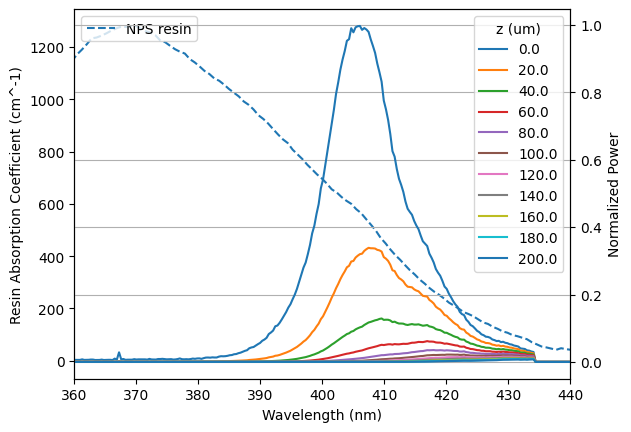

In [40]:
fig, ax = plt.subplots()
ax_right = ax.twinx()
for z in z_positions_um:
    ax_right.plot(irradiance_nps2p3.wavelengths, irradiance_nps2p3(z), label=z)
ax.set_xlim(360, 440)
ax.plot(resin_nps2p3.wavelength, resin_nps2p3.absorption_coeff_inv_cm, ls="--", label="NPS resin")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Resin Absorption Coefficient (cm^-1)")
ax_right.set_ylabel("Normalized Power")
ax_right.legend(title="z (um)")
ax.legend(loc="upper left")
ax_right.grid()